# Linear Regression Only Prototype
This notebook loads a few stocks and plots the price alongside a 13-day and a 54-day rolling Linear Regression line.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os, glob
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK_SHORT = 13
LOOKBACK_LONG = 54
PLOT_START = '2023-01-01'
PLOT_END = '2023-03-31'

WARMUP_DAYS = LOOKBACK_LONG + 10

In [2]:
# --- MATH FUNCTIONS ---
def calc_rolling_regression_line(series, window):
    """
    Calculates the exact value of the regression line on 'today' 
    for each rolling window.
    """
    reg_line_values = np.full(len(series), np.nan)
    x = np.arange(window)
    
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        slope, intercept, r_val, p_val, std_err = linregress(x, y)
        
        # The value of the line at the very end of the window (x = window - 1)
        reg_line_values[i] = (slope * (window - 1)) + intercept
        
    return pd.Series(reg_line_values, index=series.index)

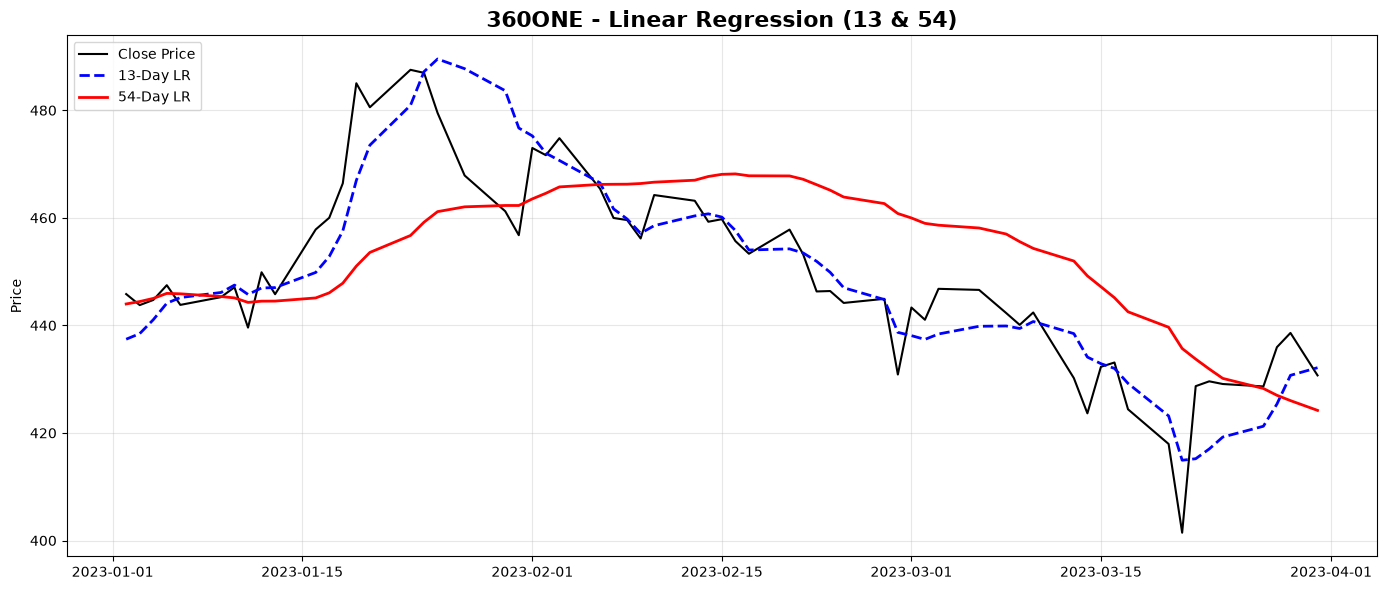

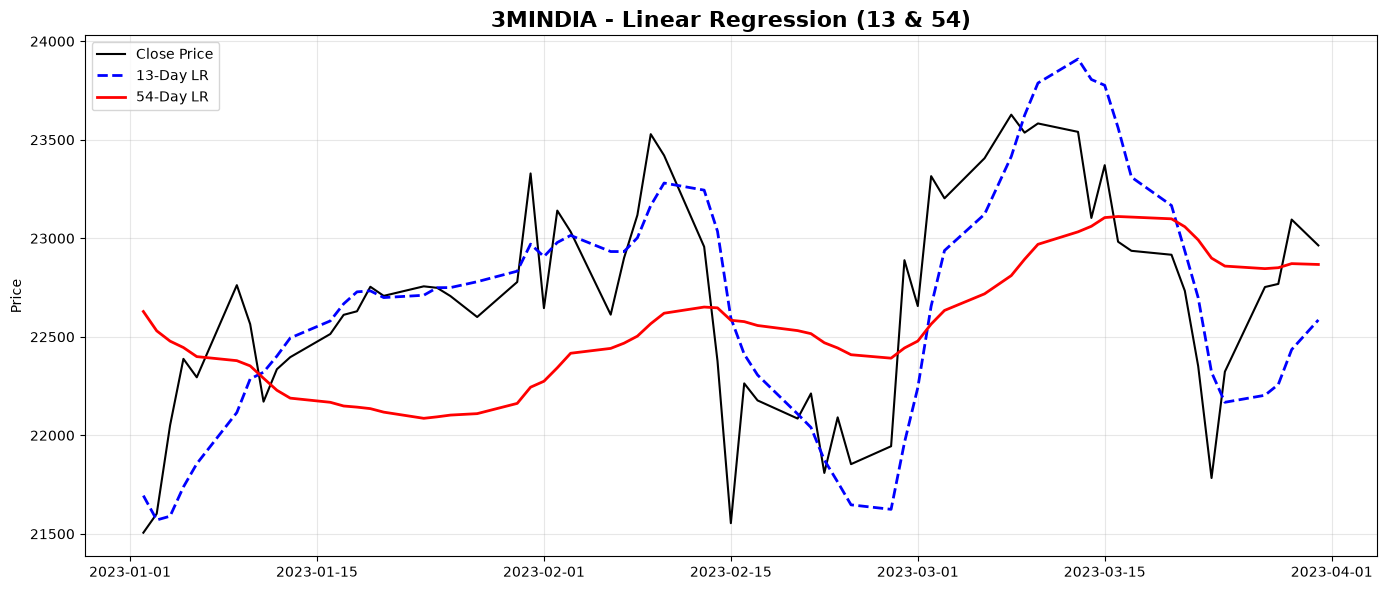

In [3]:
# --- PROCESSING & PLOTTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[:3]

for file in all_files:
    stock_name = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    try:
        start_idx = df[df['Date'] >= PLOT_START].index[0]
        load_start_idx = max(0, start_idx - WARMUP_DAYS)
        end_idx = df[df['Date'] <= PLOT_END].index[-1]
    except IndexError:
        continue 
        
    df = df.iloc[load_start_idx:end_idx+1].copy()
    
    # Calculate Regression Lines
    df['lr_13'] = calc_rolling_regression_line(df['Close'], LOOKBACK_SHORT)
    df['lr_54'] = calc_rolling_regression_line(df['Close'], LOOKBACK_LONG)
    
    # Trim Warmup
    plot_df = df[df['Date'] >= PLOT_START].copy()
    
    # --- PLOTTING ---
    plt.figure(figsize=(14, 6))
    plt.title(f"{stock_name} - Linear Regression (13 & 54)", fontsize=16, weight='bold')
    
    plt.plot(plot_df['Date'], plot_df['Close'], color='black', label='Close Price', linewidth=1.5)
    plt.plot(plot_df['Date'], plot_df['lr_13'], color='blue', linestyle='--', label='13-Day LR', linewidth=2)
    plt.plot(plot_df['Date'], plot_df['lr_54'], color='red', linestyle='-', label='54-Day LR', linewidth=2)
    
    plt.ylabel("Price")
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
